# Session 14: Gradient Descent for Multivariate Linear Regression

In this session, we will:

1. Learn the basics of **NumPy** for numerical computing
2. Understand **gradient descent** optimization
3. Implement **multivariate linear regression** from scratch


---

## Part 1: Introduction to NumPy

NumPy is the fundamental package for numerical computing in Python. It provides:

- N-dimensional arrays (`ndarray`)
- Broadcasting for element-wise operations
- Linear algebra operations
- Mathematical functions optimized for arrays


In [4]:
import numpy as np

alias


### 1.1 Creating Arrays


In [5]:
# From Python lists
arr1 = np.array([-1, 2, 3, 4, 5], dtype=np.int8)
print(f"1D array: {arr1}")
print(f"Shape: {arr1.shape}")
print(f"Dtype: {arr1.dtype}")

1D array: [-1  2  3  4  5]
Shape: (5,)
Dtype: int8


In [6]:
# 2D array (matrix)
arr2 = np.array([[1, 2, 3],
                 [4, 5, 6]])
print(f"2D array:\n{arr2}")
print(f"Shape: {arr2.shape}")  # (rows, columns)

2D array:
[[1 2 3]
 [4 5 6]]
Shape: (2, 3)


In [7]:
# Common array creation functions
zeros = np.zeros((3, 4))       # 3x4 matrix of zeros
ones = np.ones((2, 3))         # 2x3 matrix of ones
# 3x3 matrix of random values (normal distribution)
random = np.random.randn(3, 3)
arange = np.arange(0, 10, 2)   # [0, 2, 4, 6, 8]
linspace = np.linspace(0, 1, 5)  # 5 evenly spaced values from 0 to 1

print(f"zeros:\n{zeros}\n")
print(f"ones:\n{ones}\n")
print(f"random:\n{random}\n")
print(f"arange: {arange}")
print(f"linspace: {linspace}")

zeros:
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]

ones:
[[1. 1. 1.]
 [1. 1. 1.]]

random:
[[ 1.76405235  0.40015721  0.97873798]
 [ 2.2408932   1.86755799 -0.97727788]
 [ 0.95008842 -0.15135721 -0.10321885]]

arange: [0 2 4 6 8]
linspace: [0.   0.25 0.5  0.75 1.  ]


### 1.2 Array Operations and Broadcasting

NumPy operations are **element-wise** by default. Broadcasting allows operations between arrays of different shapes.


In [8]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

print(f"a + b = {a + b}")      # Element-wise addition
print(f"a * b = {a * b}")      # Element-wise multiplication
print(f"a ** 2 = {a ** 2}")    # Element-wise power
print(f"a * 10 = {a * 10}")    # Broadcasting: scalar applied to all elements

a + b = [5 7 9]
a * b = [ 4 10 18]
a ** 2 = [1 4 9]
a * 10 = [10 20 30]


In [9]:
# Broadcasting with 2D arrays
matrix = np.array([[1, 2, 3],
                   [4, 5, 6]])
row_vector = np.array([10, 20, 30])

"""
[[10, 20, 30],
[10, 20 ,30]]
"""

# The row vector is "broadcast" to each row of the matrix
result = matrix + row_vector
print(f"Matrix + row_vector:\n{result}")

Matrix + row_vector:
[[11 22 33]
 [14 25 36]]


### 1.3 Matrix Operations

For linear regression, we need matrix multiplication and transpose.


In [10]:
A = np.array([[1, 2],
              [3, 4]])
B = np.array([[5, 6],
              [7, 8]])

# Matrix multiplication (dot product)
print(f"A @ B (matrix multiplication):\n{A @ B}")
print(f"\nnp.dot(A, B):\n{np.dot(A, B)}")

# Transpose
print(f"\nA.T (transpose):\n{A.T}")

A @ B (matrix multiplication):
[[19 22]
 [43 50]]

np.dot(A, B):
[[19 22]
 [43 50]]

A.T (transpose):
[[1 3]
 [2 4]]


### 1.4 Useful Aggregation Functions


In [11]:
arr = np.array([[1, 2, 3],
                [4, 5, 6]])

print(f"Sum all: {np.sum(arr)}")
print(f"Sum along rows (axis=1): {np.sum(arr, axis=1)}")
print(f"Sum along columns (axis=0): {np.sum(arr, axis=0)}")
print(f"Mean: {np.mean(arr)}")
print(f"Std: {np.std(arr)}")

Sum all: 21
Sum along rows (axis=1): [ 6 15]
Sum along columns (axis=0): [5 7 9]
Mean: 3.5
Std: 1.707825127659933


---

## Part 2: Linear Regression Review

### What is Linear Regression?

Linear regression models the relationship between features $X$ and target $y$ as:

$$\hat{y} = X \cdot w + b$$

Where:

- $X$ is the feature matrix of shape `(n_samples, n_features)`
- $w$ is the weight vector of shape `(n_features,)`
- $b$ is the bias (intercept) scalar
- $\hat{y}$ is the predicted values

### The Goal

Find $w$ and $b$ that minimize the **Mean Squared Error (MSE)**:

$$\mathcal{L} = MSE = \frac{1}{n} \sum_{i=1}^{n} (\hat{y_i} - y_i)^2$$


### Gradients for Linear Regression

For MSE loss with linear regression, the gradients are:

$$\nabla_w \mathcal{L} = \frac{\partial \mathcal{L}}{\partial w} = \frac{\partial MSE}{\partial w} = \frac{2}{n}  (\hat{y} - y) X$$

$$\nabla_b \mathcal{L} = \frac{\partial \mathcal{L}}{\partial b} = \frac{\partial MSE}{\partial b} = \frac{2}{n} \sum(\hat{y} - y)$$

Let's derive this step by step:

1. $MSE = \frac{1}{n}\sum(\hat{y} - y)^2 = \frac{1}{n}\sum(Xw + b - y)^2$

2. Using chain rule: $\frac{\partial MSE}{\partial w} = \frac{2}{n} \cdot (Xw + b - y) \cdot X$

3. In matrix form: $\frac{\partial MSE}{\partial w} = \frac{2}{n} (\hat{y} - y) X$


---

## Part 3: Gradient Descent

### What is Gradient Descent?

Gradient descent is an optimization algorithm that iteratively updates parameters to minimize a loss function.

Think of it like descending a mountain in fog - you can only feel the slope at your current position, so you take small steps in the steepest downward direction.

### The Update Rule

$$w_{new} = w_{old} - \alpha \cdot \nabla_w \mathcal{L} = w_{old} - \alpha \cdot \frac{\partial \mathcal{L}}{\partial w} $$

Where $\alpha$ is the **learning rate** - how big of a step we take.


---

## Part 4: Implementation from Scratch

Let's build our linear regression step by step.


In [12]:
# First, let's create some synthetic data
np.random.seed(42)

# True parameters we want to learn
true_weights = np.array([2.0, -3.5, 1.5])
true_bias = 5.0

# Generate random features
n_samples = 1000
n_features = 3
X = np.random.randn(n_samples, n_features)

# Generate target with some noise
noise = np.random.randn(n_samples) * 0.5
y = X @ true_weights + true_bias + noise

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"True weights: {true_weights}")
print(f"True bias: {true_bias}")

X shape: (1000, 3)
y shape: (1000,)
True weights: [ 2.  -3.5  1.5]
True bias: 5.0


### 4.1 Core Functions


### In-class Task


Write `predict()`, `compute_mse()`, `compute_gradients()`, which perform neccessary operations for gradient descent.


In [13]:
def predict(X: np.ndarray, w: np.ndarray, b: float) -> np.ndarray:
    """
    Compute predictions for linear regression.

    Args:
        X: Feature matrix of shape (n_samples, n_features)
        w: Weight vector of shape (n_features,)
        b: Bias scalar

    Returns:
        Predictions of shape (n_samples,)
    """
    # Your code here
    return X @ w + b

In [14]:
def compute_mse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    Compute Mean Squared Error.

    Args:
        y_true: Actual target values
        y_pred: Predicted values

    Returns:
        MSE loss value
    """
    # Your code here
    return np.mean(np.sum((y_true - y_pred) ** 2))

In [15]:
def compute_gradients(X: np.ndarray, y: np.ndarray, y_pred: np.ndarray) -> tuple:
    """
    Compute gradients for weights and bias.

    Args:
        X: Feature matrix of shape (n_samples, n_features)
        y: True target values
        y_pred: Predicted values

    Returns:
        Tuple of (gradient_w, gradient_b)
    """
    # Your code here
    number_samples = len(X)
    gradient_w = (2 / number_samples * ((y_pred - y) @ X))
    gradient_b = (2 / number_samples * np.sum(y_pred - y))
    return gradient_w, gradient_b

### Compute first gradient


In [16]:
X = np.random.rand(1000, 3)
w = np.ones((3))
b = np.array([0.0])


In [17]:
X.shape, w.shape, b.shape  # Should be ((1000, 3), (3,), (1,))

((1000, 3), (3,), (1,))

In [18]:
y_pred = predict(X, w, b)  # Initial predictions
# Should print gradients (grad_w, grad_b)
print(compute_gradients(X, y, y_pred))

(array([-3.42240666, -3.72542339, -3.47389426]), np.float64(-7.436357593380485))


Can you observe what happen?


### 4.2 Training Loop


In [19]:
def train_linear_regression(
    X: np.ndarray,
    y: np.ndarray,
    learning_rate: float = 0.01,
    n_iterations: int = 1000,
    verbose: bool = True,
    log_every_n_step=25,
) -> tuple:
    """
    Train linear regression using gradient descent.

    Args:
        X: Feature matrix of shape (n_samples, n_features)
        y: Target values of shape (n_samples,)
        learning_rate: Step size for gradient descent
        n_iterations: Number of training iterations
        verbose: Whether to print progress
        log_every_n_step: Number of steps to log the result

    Returns:
        Tuple of (final_weights, final_bias, loss_history)
    """
    n_samples, n_features = X.shape

    # Initialize parameters randomly
    w = np.random.randn(n_features) * 0.01 #(3,)
    b = 0.0

    loss_history = []

    for i in range(n_iterations): 
        # Calculate y_pred (y_hat)
        y_pred = predict(X, w, b)

        # Calculate Loss (MSE)
        loss = compute_mse(y, y_pred) # y_true in compute_mse is y
        loss_history.append(loss)

        if verbose and (i % log_every_n_step == 0 or i == n_iterations - 1):
            print(f"Iteration {i:4d} | Loss: {loss:.6f}")

        # Calculate Gradients (w prime and b prime)
        grad_w, grad_b = compute_gradients(X, y, y_pred)

        # Gradient descent
        w = w - learning_rate * grad_w # follow the grad descent formula
        b = b - learning_rate * grad_b
        # Your code here
        y_pred = X @ w + b

        loss = (1 / n_samples) * np.sum((y_pred - y) ** 2)
        loss_history.append(loss)

        if verbose and (i % log_every_n_step == 0 or i == n_iterations - 1):
            print(f"Iteration {i:4d} | Loss: {loss:.6f}")

    return w, b, loss_history

In [20]:
# Train the model
learned_w, learned_b, losses = train_linear_regression(
    X, y,
    learning_rate=0.01,
    n_iterations=500
)

Iteration    0 | Loss: 45755.169581
Iteration    0 | Loss: 43.920855
Iteration   25 | Loss: 23623.207955
Iteration   25 | Loss: 23.315989
Iteration   50 | Loss: 19907.611756
Iteration   50 | Loss: 19.855597
Iteration   75 | Loss: 19270.206223
Iteration   75 | Loss: 19.260872
Iteration  100 | Loss: 19148.069017
Iteration  100 | Loss: 19.145903
Iteration  125 | Loss: 19112.902708
Iteration  125 | Loss: 19.111968
Iteration  150 | Loss: 19093.088909
Iteration  150 | Loss: 19.092392
Iteration  175 | Loss: 19076.610500
Iteration  175 | Loss: 19.075983
Iteration  200 | Loss: 19061.412546
Iteration  200 | Loss: 19.060824
Iteration  225 | Loss: 19047.107844
Iteration  225 | Loss: 19.046552
Iteration  250 | Loss: 19033.590774
Iteration  250 | Loss: 19.033066
Iteration  275 | Loss: 19020.805478
Iteration  275 | Loss: 19.020309
Iteration  300 | Loss: 19008.706929
Iteration  300 | Loss: 19.008237
Iteration  325 | Loss: 18997.254247
Iteration  325 | Loss: 18.996809
Iteration  350 | Loss: 18986.40941

In [21]:
# Compare learned parameters with true parameters
print("\n=== Results ===")
print(f"True weights:    {true_weights}")
print(f"Learned weights: {learned_w}")
print(f"\nTrue bias:    {true_bias}")
print(f"Learned bias: {learned_b:.4f}")


=== Results ===
True weights:    [ 2.  -3.5  1.5]
Learned weights: [0.84935396 1.55546453 0.78004438]

True bias:    5.0
Learned bias: 3.5705


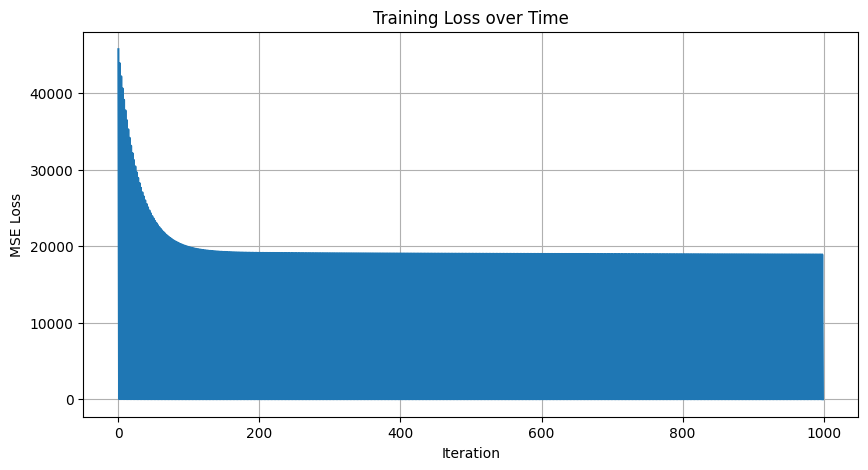

In [22]:
# Visualize the loss curve
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('Training Loss over Time')
plt.grid(True)
plt.show()

---

## Part 5: Feature Scaling

Gradient descent works much better when features are on similar scales. Let's see why and how to fix it.


This is statistical way to standarize any sameple of feature $i$ to a normal distribution:
$$X_i = \frac{x_i-\mu_i}{\sigma_i}$$
where $X_i$ is the column vector of raw data feature $i$


In [23]:
# Create data with very different scales
np.random.seed(42)
X_unscaled = np.column_stack([
    np.random.randn(500) * 1000,      # Feature 1: scale ~1000
    np.random.randn(500) * 0.001,     # Feature 2: scale ~0.001
    np.random.randn(500)              # Feature 3: scale ~1
])
y_unscaled = X_unscaled @ np.array([0.001, 1000, 1]) + \
    5 + np.random.randn(500) * 0.5

print(f"Feature ranges:")
for i in range(3):
    print(
        f"  Feature {i+1}: [{X_unscaled[:, i].min():.2f}, {X_unscaled[:, i].max():.2f}]")

Feature ranges:
  Feature 1: [-3241.27, 3852.73]
  Feature 2: [-0.00, 0.00]
  Feature 3: [-2.90, 2.60]


In [24]:
# This will likely fail or converge very slowly!
try:
    w_bad, b_bad, losses_bad = train_linear_regression(
        X_unscaled, y_unscaled, learning_rate=0.01, n_iterations=100
    )
except:
    print("Training failed due to numerical instability!")

Iteration    0 | Loss: 42848.057748
Iteration    0 | Loss: 20963979249.510815
Iteration   25 | Loss: 435577579601040749878537163018217034618512031740454354204035290740125022325350081356573846538274043475700389068208737162869682524344824263999552423288216490104208738922691361909094943482443355271961141065943348125106176.000000
Iteration   25 | Loss: 321764470795070152126857852012046645123214780474619200566197430269621987813885165843622587436481739371608133376023654739656764183175608495711778649562656529419019886615058951147305866096822700971372644504797511662815567413248.000000
Iteration   50 | Loss: inf
Iteration   50 | Loss: inf
Iteration   75 | Loss: nan
Iteration   75 | Loss: nan
Iteration   99 | Loss: nan
Iteration   99 | Loss: nan


C:\Users\Arm\AppData\Local\Temp\ipykernel_21564\3056339049.py:51: RuntimeWarning: overflow encountered in square
  loss = (1 / n_samples) * np.sum((y_pred - y) ** 2)
c:\Users\Arm\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Arm\AppData\Local\Temp\ipykernel_21564\2586926902.py:13: RuntimeWarning: overflow encountered in square
  return np.mean(np.sum((y_true - y_pred) ** 2))
C:\Users\Arm\AppData\Local\Temp\ipykernel_21564\2621650920.py:15: RuntimeWarning: overflow encountered in matmul
  gradient_w = (2 / number_samples * ((y_pred - y) @ X))
C:\Users\Arm\AppData\Local\Temp\ipykernel_21564\2621650920.py:15: RuntimeWarning: invalid value encountered in matmul
  gradient_w = (2 / number_samples * ((y_pred - y) @ X))
c:\Users\Arm\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: i

### Task: Implement standardize function


In [25]:
# Solution: Standardization (Z-score normalization)
def standardize(X: np.ndarray) -> tuple:
    """
    Standardize features to have mean=0 and std=1.

    Returns:
        Tuple of (X_standardized, mean, std)
    """
    # Your code here
    mean_each_column = np.mean(X, axis=0) #axis cannot be 1 because we want the mean of each column and not row
    sd_each_column = np.std(X, axis=0) # sigma_i
    X_scaled = (X - mean_each_column) / sd_each_column
    return X_scaled, mean_each_column, sd_each_column

In [26]:
# Standardize and train
X_scaled, X_mean, X_std = standardize(X_unscaled)

print(f"Scaled feature ranges:")
for i in range(3):
    print(
        f"  Feature {i+1}: [{X_scaled[:, i].min():.2f}, {X_scaled[:, i].max():.2f}]")

w_good, b_good, losses_good = train_linear_regression(
    X_scaled, y_unscaled, learning_rate=0.1, n_iterations=500
)

Scaled feature ranges:
  Feature 1: [-3.31, 3.92]
  Feature 2: [-2.79, 2.66]
  Feature 3: [-2.98, 2.47]
Iteration    0 | Loss: 14893.952513
Iteration    0 | Loss: 19.183788
Iteration   25 | Loss: 120.469274
Iteration   25 | Loss: 0.240775
Iteration   50 | Loss: 120.239388
Iteration   50 | Loss: 0.240479
Iteration   75 | Loss: 120.239384
Iteration   75 | Loss: 0.240479
Iteration  100 | Loss: 120.239384
Iteration  100 | Loss: 0.240479
Iteration  125 | Loss: 120.239384
Iteration  125 | Loss: 0.240479
Iteration  150 | Loss: 120.239384
Iteration  150 | Loss: 0.240479
Iteration  175 | Loss: 120.239384
Iteration  175 | Loss: 0.240479
Iteration  200 | Loss: 120.239384
Iteration  200 | Loss: 0.240479
Iteration  225 | Loss: 120.239384
Iteration  225 | Loss: 0.240479
Iteration  250 | Loss: 120.239384
Iteration  250 | Loss: 0.240479
Iteration  275 | Loss: 120.239384
Iteration  275 | Loss: 0.240479
Iteration  300 | Loss: 120.239384
Iteration  300 | Loss: 0.240479
Iteration  325 | Loss: 120.239384
I

---

# Tasks (Deadline: Sunday 30th Nov 2025)

Complete the following tasks to practice implementing gradient descent for linear regression.


## Task 1: Implement Mini-Batch Gradient Descent

Instead of using all samples in each iteration (batch gradient descent), implement **mini-batch gradient descent** which uses a random subset of samples.

Formally said, choose $X_b$ and its corresponding $y_b$ which is a subset of $row(X), row(y)$ to be trained for each iteration.

Benefits of mini-batch:

- Faster iterations
- Can escape local minima
- Better generalization

```python
# Expected usage:
w, b, losses = train_minibatch_gd(X, y, batch_size=32, learning_rate=0.01, n_iterations=1000)
```


# three types of GD:
batch gradient descent


stochastic gradient descent


mini batch gradient descent


!!!
also batch gradient descent downside is that if there are many samples then it will take really long time or in other case you device explodes

In [27]:
def train_minibatch_gd(
    X: np.ndarray,
    y: np.ndarray,
    batch_size: int = 32,
    learning_rate: float = 0.01,
    n_iterations: int = 1000,
    verbose: bool = True,
    log_every_n_step: int = 20,
) -> tuple:
    """
    Train linear regression using mini-batch gradient descent.

    Hints:
    - Use np.random.choice to select random indices
    - Compute gradients using only the selected samples
    """
    n_samples, n_features = X.shape

    # Initialize parameters randomly
    w = np.random.randn(n_features) * 0.01
    b = 0.0

    loss_history = []

    for i in range(n_iterations):
        # Your code here
        # just pick random batch indices
        batch_indices = np.random.choice(n_samples, batch_size, replace = False)

        X_batch = X[batch_indices]
        y_batch = y[batch_indices]

        y_pred = X_batch @ w + b  # Predictions

        error = y_pred - y_batch
        grad_w = (1 / batch_size) * (X_batch.T @ error)
        grad_b = (1 / batch_size) * np.sum(error)

        w -= learning_rate * grad_w
        b -= learning_rate * grad_b
        loss = np.mean(error ** 2)
        loss_history.append(loss)

        if verbose and (i % log_every_n_step == 0 or i == n_iterations - 1):
            print(f"Iteration {i:4d} | Loss: {loss:.6f}")

    return w, b, loss_history

In [28]:
_, _, loss_history = train_minibatch_gd(
    X, y,
    batch_size=64,
    learning_rate=0.01,
    n_iterations=200,
    log_every_n_step=50
)

Iteration    0 | Loss: 47.685217
Iteration   50 | Loss: 24.157552
Iteration  100 | Loss: 20.130659
Iteration  150 | Loss: 23.057674
Iteration  199 | Loss: 12.970125


## Task 2: Implement Learning Rate Scheduling

Implement a training function that **decreases the learning rate** over time. This helps converge more precisely at the end of training.

Common schedules:

- Step decay: $\alpha_t = \alpha_0 \cdot 0.9^{\lfloor t/100 \rfloor}$
- Exponential decay: $\alpha_t = \alpha_0 \cdot e^{-kt}$
- Inverse time: $\alpha_t = \frac{\alpha_0}{1 + k \cdot t}$

where $t$ is number of current step/iteration and $k$ is the decay constant


In [29]:
def train_with_lr_schedule(
    X: np.ndarray,
    y: np.ndarray,
    initial_lr: float = 0.1,
    schedule: str = 'exponential',  # 'step', 'exponential', or 'inverse'
    n_iterations: int = 1000,
    decay_constant: float = 0.0001,
) -> tuple:
    """
    Train with learning rate scheduling.

    Implement at least one scheduling strategy.
    """
    n_samples, n_features = X.shape
    w = np.random.randn(n_features) * 0.01
    b = 0.0

    learning_rate = initial_lr
    loss_history = []
    for i in range(n_iterations):
        # Your code here
        if schedule == "step":
            learning_rate = initial_lr / (1 + decay_constant * i)

        elif schedule == "exponential":
            learning_rate = initial_lr * np.exp(-decay_constant * i)

        elif schedule == "inverse":
            learning_rate = initial_lr / (1 + decay_constant * i)

        else:
            learning_rate = initial_lr

        y_pred = X @ w + b
        error = y_pred - y
        grad_w = (1 / n_samples) * (X.T @ error)
        grad_b = (1 / n_samples) * np.sum(error)

        w -= learning_rate * grad_w
        b -= learning_rate * grad_b
        loss = np.mean(error ** 2)
        loss_history.append(loss)

        if i % 100 == 0 or i == n_iterations - 1:
            print(f"Iteration {i}, Loss: {loss:.6f}, LR: {learning_rate:.6f}")


    return w, b, loss_history

In [30]:
# Test them all:
print("Step decay:")
_, _, loss_history = train_with_lr_schedule(
    X, y,
    initial_lr=0.01,
    schedule='step',
    n_iterations=500,
    decay_constant=0.0001
)

print("Exponential decay:")
_, _, loss_history = train_with_lr_schedule(
    X, y,
    initial_lr=0.01,
    schedule='exponential',
    n_iterations=500,
    decay_constant=0.0001
)

print("Inverse time decay:")
_, _, loss_history = train_with_lr_schedule(
    X, y,
    initial_lr=0.01,
    schedule='inverse',
    n_iterations=500,
    decay_constant=0.0001
)

Step decay:
Iteration 0, Loss: 45.941854, LR: 0.010000
Iteration 100, Loss: 19.949264, LR: 0.009901
Iteration 200, Loss: 19.150193, LR: 0.009804
Iteration 300, Loss: 19.093011, LR: 0.009709
Iteration 400, Loss: 19.062069, LR: 0.009615
Iteration 499, Loss: 19.035454, LR: 0.009525
Exponential decay:
Iteration 0, Loss: 46.038020, LR: 0.010000
Iteration 100, Loss: 19.950323, LR: 0.009900
Iteration 200, Loss: 19.148609, LR: 0.009802
Iteration 300, Loss: 19.091504, LR: 0.009704
Iteration 400, Loss: 19.060718, LR: 0.009608
Iteration 499, Loss: 19.034252, LR: 0.009513
Inverse time decay:
Iteration 0, Loss: 45.909777, LR: 0.010000
Iteration 100, Loss: 19.950846, LR: 0.009901
Iteration 200, Loss: 19.152422, LR: 0.009804
Iteration 300, Loss: 19.094973, LR: 0.009709
Iteration 400, Loss: 19.063777, LR: 0.009615
Iteration 499, Loss: 19.036948, LR: 0.009525


## Task 3: Add Regularization (Ridge Regression)

Implement **L2 regularization** (Ridge regression) to prevent overfitting.

The loss function becomes:
$$\mathcal{L} = \mathcal{L}_{MSE} + \lambda \sum w_i^2$$

The gradient for weights becomes:
$$\frac{\partial Loss}{\partial w} = \frac{\partial MSE}{\partial w} + 2\lambda w$$

where $\lambda$ is the regularization constant and $w_i$ is the weight value of corresponding feature $i$


In [31]:
def calculate_ridge_loss(y_true: np.ndarray, y_pred: np.ndarray, w: np.ndarray, reg_lambda: float) -> float:
    """
    Compute Ridge regression loss (MSE + L2 regularization).

    Args:
        y_true: Actual target values
        y_pred: Predicted values
        w: Weight vector
        reg_lambda: Regularization strength

    Returns:
        Ridge loss value
    """
    # Your code here
    mse = np.mean((y_true - y_pred) ** 2)
    rl = reg_lambda * np.sum(w ** 2)
    return mse + rl


def calculate_ridge_gradients(X: np.ndarray, y: np.ndarray, y_pred: np.ndarray, w: np.ndarray, reg_lambda: float) -> tuple:
    """
    Compute gradients for Ridge regression.

    Args:
        X: Feature matrix
        y: True target values
        y_pred: Predicted values
        w: Weight vector
        reg_lambda: Regularization strength
        """
    # Your code here
    n = len(y)
    error = y_pred - y

    grad_w = (2/n) * (X.T @ error) + 2 * reg_lambda * w
    grad_b = (2/n) * np.sum(error)

    return grad_w, grad_b


def train_ridge_regression(
    X: np.ndarray,
    y: np.ndarray,
    learning_rate: float = 0.01,
    reg_lambda: float = 0.1,  # Regularization strength
    n_iterations: int = 1000
) -> tuple:
    """
    Train linear regression with L2 regularization.

    Hints:
    - Modify the loss calculation to include regularization term
    - Modify the gradient calculation for weights
    - Note: We typically don't regularize the bias term
    """
    # Your code here
    n_features = X.shape[1]
    w = np.zeros(n_features)
    b = 0.0

    for _ in range(n_iterations):
        y_pred = X @ w + b

        grad_w, grad_b = calculate_ridge_gradients(X, y, y_pred, w, reg_lambda)

        w -= learning_rate * grad_w
        b -= learning_rate * grad_b

    return w, b, loss_history

In [32]:
w, b, loss_history = train_ridge_regression(
    X, y,
    learning_rate=0.01,
    reg_lambda=0.1,
    n_iterations=500
)

## Bonus Task: Implement Stochastic Gradient Descent (SGD)

Implement pure SGD where you update weights after **each individual sample** (batch_size=1).

Compare the convergence behavior of:

1. Batch GD (all samples)
2. Mini-batch GD (e.g., 32 samples)
3. SGD (1 sample)

Plot the loss curves for all three on the same graph.


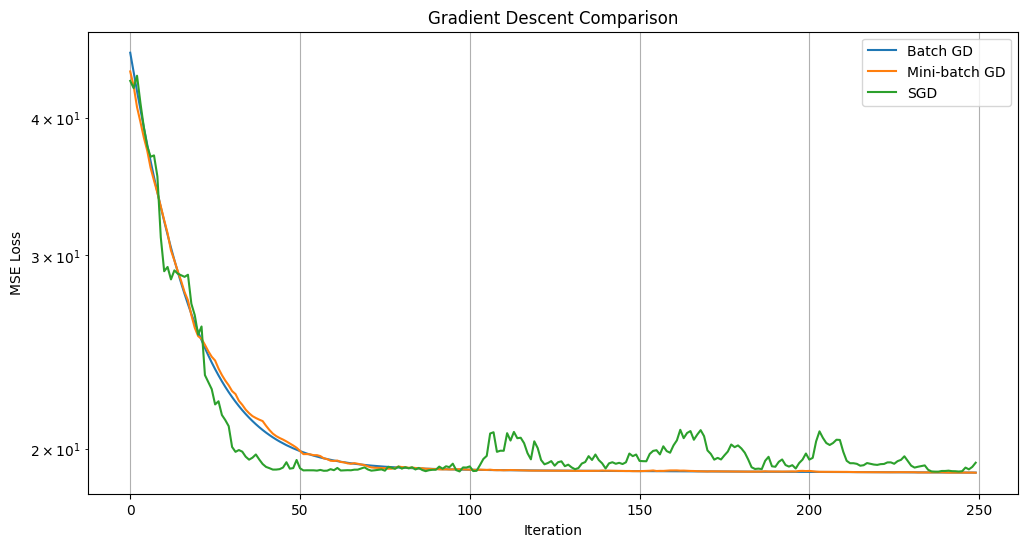

In [ ]:
# Your code here
import matplotlib.pyplot as plt
import numpy as np

def train_batch_gd(X, y, learning_rate=0.01, n_iterations=250):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    bias = 0.0
    loss_history = []

    for _ in range(n_iterations):
        predictions = X @ weights + bias
        errors = predictions - y

        grad_weights = (2 / n_samples) * (X.T @ errors)
        grad_bias = (2 / n_samples) * np.sum(errors)

        weights -= learning_rate * grad_weights
        bias -= learning_rate * grad_bias

        loss_history.append(np.mean(errors ** 2))  # MSE
    return loss_history

# ------------------- Mini-batch Gradient Descent -------------------
def train_mini_batch_gd(X, y, batch_size=32, learning_rate=0.01, n_iterations=250):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    bias = 0.0
    loss_history = []

    for _ in range(n_iterations):
        batch_indices = np.random.choice(n_samples, batch_size, replace=False)
        X_batch = X[batch_indices]
        y_batch = y[batch_indices]

        predictions = X_batch @ weights + bias
        errors = predictions - y_batch

        grad_weights = (2 / batch_size) * (X_batch.T @ errors)
        grad_bias = (2 / batch_size) * np.sum(errors)

        weights -= learning_rate * grad_weights
        bias -= learning_rate * grad_bias

        # Compute loss on all data
        full_predictions = X @ weights + bias
        loss_history.append(np.mean((full_predictions - y) ** 2))
    return loss_history

# ------------------- Stochastic Gradient Descent (SGD) -------------------
def train_sgd(X, y, learning_rate=0.01, n_iterations=250):
    return train_mini_batch_gd(X, y, batch_size=1, learning_rate=learning_rate, n_iterations=n_iterations)

# ------------------- Train and Plot -------------------
np.random.seed(0)
loss_batch_gd = train_batch_gd(X, y)
np.random.seed(0)
loss_mini_batch_gd = train_mini_batch_gd(X, y)
np.random.seed(0)
loss_sgd = train_sgd(X, y)

plt.figure(figsize=(12, 6))
plt.plot(loss_batch_gd, label="Batch GD")
plt.plot(loss_mini_batch_gd, label="Mini-batch GD")
plt.plot(loss_sgd, label="SGD")
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.title("Gradient Descent Comparison")
plt.grid(True)
plt.legend()
plt.show()